# Structural Variant Discovery, Genotyping and Analyses
## Variant Discovery with SMOOVE
Structural variant (SV) analyses followed a similar pipeline where variant discovery, variant quality filtering, and initial genotyping was performed under recommended pipelines. High quality genotypes representing homozygous reference, heterozygous and homozygous alternate calls were then plotted with SAMplot and evaluated using PlotCritic for call refinement. Calls passing evaluation with PlotCritic were then merged using SURVIVOR and used to construct a genome graph with the VG tools suite. Detailed methods for each of these steps using Delly, and Smoove are outlined below.  

In [ ]:
#!/bin/bash -e
#SBATCH --account uc03718
#SBATCH --job-name initial_smoove_calls
#SBATCH --cpus-per-task=32
#SBATCH --mem=32G
#SBATCH --time 02:00:00  # Walltime (HH:MM:SS)
#SBATCH --output /nesi/nobackup/uc03718/smoove/slurms/TI_smoove_call_%A.%a.out
#SBATCH --error /nesi/nobackup/uc03718/smoove/slurms/TI_smoove_call__%A.%a.err
#SBATCH --profile=ALL

REF=/nesi/nobackup/uc03718/new_TI/hifiasm_longstitch_racon_ragtag/Katie_racon_ragtag_autosomes.fa
OUT=/nesi/nobackup/uc03718/smoove/calls/

ml purge
ml smoove/0.2.8-Miniconda3

SAMP=$(sed -n "$((SLURM_ARRAY_TASK_ID +1))p" /nesi/nobackup/uc03718/smoove/TI.list)
NAME=$(basename ${SAMP} _autosomes_nodup.bam)

smoove call --outdir ${OUT} --name ${NAME} --fasta ${REF} -p 1 --genotype ${SAMP}

Merging calls

In [ ]:
smoove merge --name 00_AU_merged --outdir ./ -f $REF calls/AU*.vcf.gz
smoove merge --name 00_TI_merged --outdir ./ -f $REF calls/{SND,SP,TI}*.vcf.gz
smoove merge --name 00_GLOBAL_merged --outdir ./ -f $REF calls/{AU,SND,SP,TI}*.vcf.gz
smoove merge --name 00_KI_merged --outdir ./ -f $REF calls/H*{0..9}.vcf.gz

## SMOOVE Genotyping


In [ ]:
#!/bin/bash -e
#SBATCH --account uc03718
#SBATCH --job-name GLOBAL_smoove_genos
#SBATCH --cpus-per-task=16
#SBATCH --mem=32G
#SBATCH --time 04:00:00  # Walltime (HH:MM:SS)
#SBATCH --output /nesi/nobackup/uc03718/smoove/slurms/GLOBAL_smoove_genos_%A.%a.out
#SBATCH --error /nesi/nobackup/uc03718/smoove/slurms/GLOBAL_smoove_genos_%A.%a.err
#SBATCH --profile=ALL

REF=/nesi/nobackup/uc03718/new_TI/hifiasm_longstitch_racon_ragtag/Katie_racon_ragtag_autosomes.fa
OUT=/nesi/nobackup/uc03718/smoove/

ml purge
ml smoove/0.2.8-Miniconda3

SAMP=$(sed -n "$((SLURM_ARRAY_TASK_ID +1))p" /nesi/nobackup/uc03718/smoove/sample.list)
NAME=$(basename ${SAMP} _autosomes_nodup.bam)

smoove genotype -d -x -p 1 --name ${NAME}_GLOBALsites --outdir ${OUT}genotypes/ --fasta $REF --vcf ${OUT}00_GLOBAL_merged.sites.vcf.gz ${SAMP}

Once all samples were individually genotyped for sites called for their populations, and the two fairy tern populations genotyped for GLOBAL sites, all genotypes were then merged into their respective population data sets.  

In [ ]:
smoove paste --name 01_AU_genotypes genotypes/*_AUsites-smoove.genotyped.vcf.gz
smoove paste --name 01_TI_genotypes genotypes/*_TIsites-smoove.genotyped.vcf.gz
smoove paste --name 01_GLOBAL_genotypes genotypes/*_GLOBALsites-smoove.genotyped.vcf.gz
smoove paste --name 01_KI_genotypes genotypes/H*smoove.gentoyped.vcf.gz

smoove annotate --gff ${cohort}_scBUSCOs.gff3.gz \
    $cohort.smoove.square.vcf.gz | bgzip -c > $cohort.smoove.square.anno.vcf.gz

In [ ]:
zcat SIFT_DB/fairy_database/gene-annotation-src/merged_scBUSCO_checked.gtf.gz | awk '{if ($3=="gene") print $0}' > smoove/TI_scBUSCOs.gff

After merging of all individual genotypes, the final VCF was then filtered for variant quality.  

In [ ]:
bcftools view -i 'SVTYPE!="BND" & INFO/IMPRECISE!=1 & N_PASS(GT="mis")=0' 01_GLOBAL_genotypes.smoove.square.vcf.gz | \
    bcftools view -i '(SVTYPE = "DEL" & FMT/DHFFC[0-56] < 0.7) | (SVTYPE = "DUP" & FMT/DHBFC[0-56] > 1.3) | (SVTYPE = "INV")' -O b -o 02_GLOBAL_filtered.bcf

## SV Evaluation
### Manta
Genotypes were visually inspected for support by plotting with SAMplot and scoring with [PlotCritic](https://github.com/jbelyeu/PlotCritic). As with Smeds et al. only one curator was used to prevent the overfiltering of genotypes. We used BCFtools to first extract regions of interest for each individual.

In [ ]:
bcftools view -i 'SVTYPE=!"INS" & GT=="RR"' -f '[%CHROM\t%POS\t%END\t%SVTYPE\t%SAMPLE\thomRef\n]' 02_fairy_genotypes_filtered.vcf.gz > fairy_samplot_regions.tsv
bcftools view -i 'SVTYPE=!"INS" & GT=="het"' -f '[%CHROM\t%POS\t%END\t%SVTYPE\t%SAMPLE\thet\n]' 02_fairy_genotypes_filtered.vcf.gz >> fairy_samplot_regions.tsv
bcftools view -i 'SVTYPE=!"INS" & GT=="AA"' -f '[%CHROM\t%POS\t%END\t%SVTYPE\t%SAMPLE\thomAlt\n]' 02_fairy_genotypes_filtered.vcf.gz >> fairy_samplot_regions.tsv

bcftools view -i 'SVTYPE=!"INS" & GT=="RR"' -f '[%CHROM\t%POS\t%END\t%SVTYPE\t%SAMPLE\thomRef\n]' 02_kaki_genotypes_filtered.vcf.gz > kaki_samplot_regions.tsv
bcftools view -i 'SVTYPE=!"INS" & GT=="het"' -f '[%CHROM\t%POS\t%END\t%SVTYPE\t%SAMPLE\thet\n]' 02_kaki_genotypes_filtered.vcf.gz >> kaki_samplot_regions.tsv
bcftools view -i 'SVTYPE=!"INS" & GT=="AA"' -f '[%CHROM\t%POS\t%END\t%SVTYPE\t%SAMPLE\thomAlt\n]' 02_kaki_genotypes_filtered.vcf.gz >> kaki_samplot_regions.tsv

These regions were then plotted into individual folders with SAMPLOT for each dataset.  

In [ ]:
while read -r line
    do
    CHROM=$(echo $line | awk '{print $1}')
    START=$(echo $line | awk '{print $2}')
    ENDIN=$(echo $line | awk '{print $3}')
    SVTYP=$(echo $line | awk '{print $4}')
    SAMPL=$(echo $line | awk '{print $5}')
    GENOS=$(echo $line | awk '{print $6}')
    printf "STARTED SAMPLOT FOR $SAMPL ${CHROM}:${START} AT "
    date
    samplot plot -n ${SAMPL} -b alignments/${SAMPL}_nodup_autosomes.bam \
        -o fairy_SAMplot/${SVTYP}_${CHROM}_${START}_${ENDIN}_${SAMPLE}_${GENOS}.png \
        -c $CHROM \
        -s $START \
        -e $ENDIN \
        -t $SVTYP
done < fairy_samplot_regions.tsv

We then created PlotCritic projects and manually scored all SV genotypes.  

In [ ]:
plotcritic -p fairy_genos -i fairy_SAMplot/ -q "What is the Genotype? -A "a":"HomRef" "b":"Het" "c":"HomAlt"
plotcritic -p kaki_genos -i kaki_SAMplot/ -q "What is the Genotype? -A "a":"HomRef" "b":"Het" "c":"HomAlt"

Scored genotypes were then extracted from the PlotCritic Summary files upon completion of scoring

In [ ]:
printf "Chromosome\tPosition\tEnd\tSV_type\tSample\tGraphTyper_GT\thomRef_score\thet_score\thomAlt_score\n" > {kaki,fairy}_scores.tsv
tail -n+4 fairy_genos/fairy_genos_summary_report.tsv | tr '_' '\t' | awk '{print $2"_"$3"\t"$4"\t"$5"\t"$1"\t"$6"\t"$7"\t"$8"\t"$9"\t"$10}' >> fairy_scores.tsv

printf "Chromosome\tPosition\tEnd\tSV_Type\tSample\tGraphTyper_GT\tPlotCritic_GT\n" > fairy_genos.tsv
tail -n+2 fairy_scores.tsv | awk '{if ($7==100) print $1"\t"$2"\t"$3"\t"$4"\t"$5"\t"$6"\t0";
    else if ($8==100) print $1"\t"$2"\t"$3"\t"$4"\t"$5"\t"$6"\t1";
    else if ($9==100) print $1"\t"$2"\t"$3"\t"$4"\t"$5"\t"$6"\t2"}' >> fairy_genos.tsv

tail -n+4 kaki_genos/kaki_genos_summary_report.tsv | tr '_' '\t' | awk '{print $2"_"$3"\t"$4"\t"$5"\t"$1"\t$6"\t"$7"\t"$8"\t"$9"\t"$10}' >> kaki_scores.tsv
awk '{if ($7==100) print $1"\t"$3"\t"$3"\t"$4"\t"$5"\t"$6"\t0";
    else if ($8==100) print $1"\t"$3"\t"$3"\t"$4"\t"$5"\t"$6"\t1";
    else if ($9==100) print $1"\t"$3"\t"$3"\t"$4"\t"$5"\t"$6"\t2"}' kaki_scores.tsv >> kaki_genos.tsv

The number counts of each genotype for each individual were then acquired as below.

In [ ]:
tail -n+2 fairy_genos.tsv | cut -f5,7 | sort | uniq -c

## Structural Variant Characteristics
### Count Comparisons
Next we examine the number of SVs by type found within the fairy tern species complex and each of the kakī data sets examined here. We first counted the total Number of SVs found in Manta, those passing SV quality threshold and used as input for genotyping and finally those that passed genotyping filters. 

In [ ]:
printf "Chromosome\tPosition\tSV Type\tLength\tDataset\tPopulation\n" > SV_characteristics.tsv

for POP in AU TI GLOBAL KI
    do
    echo $POP
    bcftools query -f "%CHROM\t%POS\t%SVTYPE\t%SVLEN\tSmoove Unfiltered\t${POP}\n" 00_${POP}_merged.sites.vcf.gz >> SV_characteristics.tsv
    bcftools query -f "%CHROM\t%POS\t%SVTYPE\t%SVLEN\tSmoove filtered\t${POP}\n" 02_${POP}_filtered.bcf >> SV_characteristics.tsv
done

Then loaded our environment for plotting

In [ ]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib.legend_handler import HandlerTuple
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

path = '/nesi/nobackup/uc03718/'
os.chdir(path)
print(os.getcwd())

In [2]:
SVs = pd.read_csv('smoove/SV_characteristics.tsv', delimiter='\t')
SVs = SVs[SVs['SV Type']!='.']

auSVs = SVs[SVs['Population']=='AU']
tiSVs = SVs[SVs['Population']=='TI']
glSVs = SVs[SVs['Population']=='GLOBAL']
kiSVs = SVs[SVs['Population']=='KI']

SVs.head()

,Chromosome,Position,SV Type,Length,Dataset,Population
0,CM020437.1_RagTag,117049698,BND,.,Smoove Unfiltered,AU
1,CM020438.1_RagTag,32387641,BND,.,Smoove Unfiltered,AU
2,CM020437.1_RagTag,124552108,BND,.,Smoove Unfiltered,AU
3,CM020438.1_RagTag,167204298,BND,.,Smoove Unfiltered,AU
4,CM020437.1_RagTag,153678011,BND,.,Smoove Unfiltered,AU


In [3]:
print(sns.color_palette('colorblind').as_hex())

['#0173b2', '#de8f05', '#029e73', '#d55e00', '#cc78bc', '#ca9161', '#fbafe4', '#949494', '#ece133', '#56b4e9']


/tmp/ipykernel_22577/3386858060.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0,1].set_xticklabels(['Deletions', 'Duplications', 'Inversions'], rotation=45)
/tmp/ipykernel_22577/3386858060.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[3,0].set_xticklabels(['Deletions', 'Duplications', 'Inversions'], rotation=45, fontsize=18)
/tmp/ipykernel_22577/3386858060.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[3,1].set_xticklabels(['Deletions', 'Duplications', 'Inversions'], rotation=45, fontsize=18)


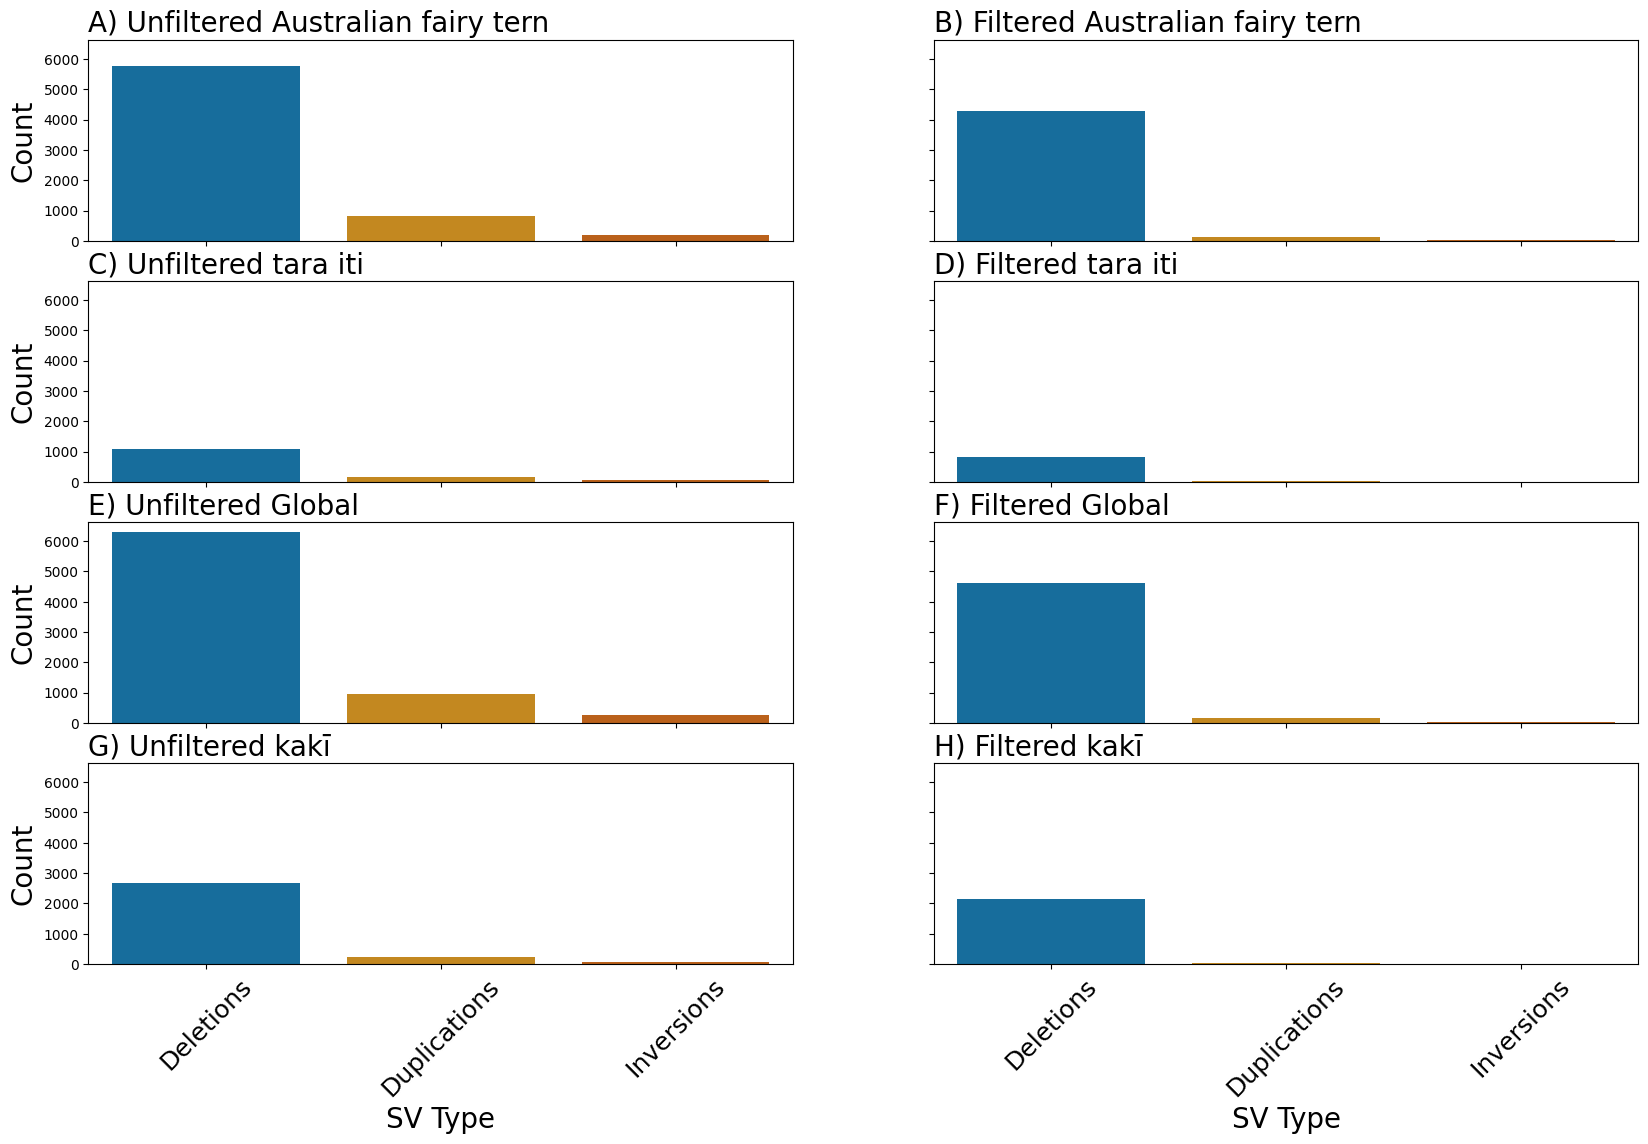

In [14]:
palette = {
    'BND': '#56b4e9',
    'DEL': '#0173b2',
    'DUP': '#de8f05',
    'INV': '#d55e00'
}
order = ['DEL', 'DUP', 'INV']

fig, axes = plt.subplots(4, 2, figsize=(20, 12), sharex=True, sharey=True)

sns.countplot(auSVs[auSVs['Dataset']=='Smoove Unfiltered'], x='SV Type', hue='SV Type', order=order, palette=palette, ax=axes[0,0])
axes[0,0].set_title('A) Unfiltered Australian fairy tern', fontsize=20, loc='left')
axes[0,0].set_ylabel('Count', fontsize=20)
#axes[0,0].set_ylim(0, 6000)
sns.countplot(auSVs[auSVs['Dataset']=='Smoove filtered'], x='SV Type', hue='SV Type', order=order, palette=palette, ax=axes[0,1])
axes[0,1].set_title('B) Filtered Australian fairy tern', fontsize=20, loc='left')
axes[0,1].set_xlabel('SV Type', fontsize=20)
axes[0,1].set_ylabel('')
axes[0,1].set_xticklabels(['Deletions', 'Duplications', 'Inversions'], rotation=45)
#axes[0,1].set_ylim(0, 4500)

sns.countplot(tiSVs[tiSVs['Dataset']=='Smoove Unfiltered'], x='SV Type', hue='SV Type', order=order, palette=palette, ax=axes[1,0])
axes[1,0].set_title('C) Unfiltered tara iti', fontsize=20, loc='left')
axes[1,0].set_ylabel('Count', fontsize=20)
#axes[1,0].set_ylim(0, 6000)
sns.countplot(tiSVs[tiSVs['Dataset']=='Smoove filtered'], x='SV Type', hue='SV Type', order=order, palette=palette, ax=axes[1,1])
axes[1,1].set_title('D) Filtered tara iti', fontsize=20, loc='left')
axes[1,1].set_ylabel('')
#axes[1,1].set_ylim(0, 4500)

sns.countplot(glSVs[glSVs['Dataset']=='Smoove Unfiltered'], x='SV Type', hue='SV Type', order=order, palette=palette, ax=axes[2,0])
axes[2,0].set_title('E) Unfiltered Global', fontsize=20, loc='left')
axes[2,0].set_ylabel('Count', fontsize=20)
#axes[2,0].set_ylim(0, 6000)
sns.countplot(glSVs[glSVs['Dataset']=='Smoove filtered'], x='SV Type', hue='SV Type', order=order, palette=palette, ax=axes[2,1])
axes[2,1].set_title('F) Filtered Global', fontsize=20, loc='left')
axes[2,1].set_ylabel('')
#axes[2,1].set_ylim(0, 4500)

sns.countplot(kiSVs[kiSVs['Dataset']=='Smoove Unfiltered'], x='SV Type', hue='SV Type', order=order, palette=palette, ax=axes[3,0])
axes[3,0].set_title('G) Unfiltered kakī', fontsize=20, loc='left')
axes[3,0].set_ylabel('Count', fontsize=20)
axes[3,0].set_xlabel('SV Type', fontsize=20)
axes[3,0].set_xticklabels(['Deletions', 'Duplications', 'Inversions'], rotation=45, fontsize=18)
#axes[3,0].set_ylim(0, 6000)
sns.countplot(kiSVs[kiSVs['Dataset']=='Smoove filtered'], x='SV Type', hue='SV Type', order=order, palette=palette, ax=axes[3,1])
axes[3,1].set_title('H) Filtered kakī', fontsize=20, loc='left')
axes[3,1].set_xlabel('SV Type', fontsize=20)
axes[3,1].set_xticklabels(['Deletions', 'Duplications', 'Inversions'], rotation=45, fontsize=18)
axes[3,1].set_ylabel('')
#axes[3,1].set_ylim(0, 4500)

plt.savefig('Git_Repos/2026_S_nereis_Cons_Gen/Figures/SV_counts.png', dpi=300, bbox_inches='tight')

Counts per chromosome

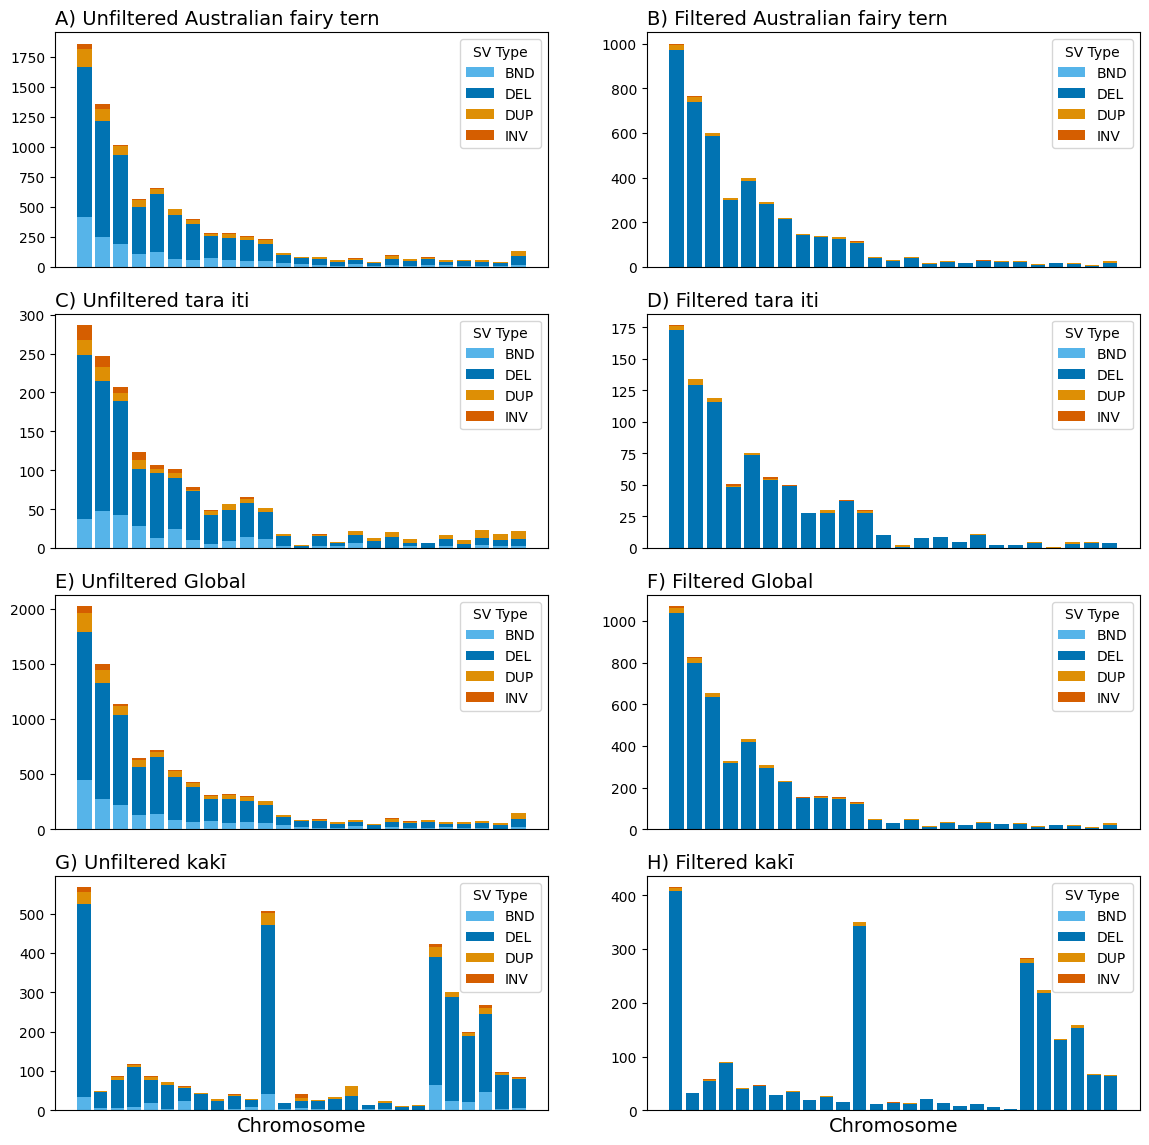

In [19]:
SVs = pd.read_csv('smoove/SV_characteristics.tsv', delimiter='\t')
SVs = SVs[SVs['SV Type']!='.']

auSVs = SVs[SVs['Population']=='AU']
tiSVs = SVs[SVs['Population']=='TI']
glSVs = SVs[SVs['Population']=='GLOBAL']
kiSVs = SVs[SVs['Population']=='KI']

palette = {
    'BND': '#56b4e9',
    'DEL': '#0173b2',
    'DUP': '#de8f05',
    'INS': '#029e73',
    'INV': '#d55e00'
}
order = ['BND', 'DEL', 'DUP', 'INV']

def plot_stacked_bar(data, dataset, ax, title):
    crosstab = pd.crosstab(data[data['Dataset'] == dataset]['Chromosome'], data[data['Dataset'] == dataset]['SV Type']).reindex(columns=order, fill_value=0)
    bottom = np.zeros(len(crosstab))
    for sv_type in order:
        ax.bar(crosstab.index, crosstab[sv_type], bottom=bottom, label=sv_type, color=palette[sv_type])
        bottom += crosstab[sv_type]
    ax.set_title(title, fontsize=14, loc='left')
    ax.set_xticks([])
    ax.set_ylabel('')
    ax.legend(title='SV Type')

fig, axes = plt.subplots(4, 2, figsize=(14, 14), sharex=False, sharey=False)

plot_stacked_bar(auSVs, 'Smoove Unfiltered', axes[0,0], 'A) Unfiltered Australian fairy tern')
plot_stacked_bar(auSVs, 'Smoove filtered', axes[0,1], 'B) Filtered Australian fairy tern')
plot_stacked_bar(tiSVs, 'Smoove Unfiltered', axes[1,0], 'C) Unfiltered tara iti')
plot_stacked_bar(tiSVs, 'Smoove filtered', axes[1,1], 'D) Filtered tara iti')
plot_stacked_bar(glSVs, 'Smoove Unfiltered', axes[2,0], 'E) Unfiltered Global')
plot_stacked_bar(glSVs, 'Smoove filtered', axes[2,1], 'F) Filtered Global')
plot_stacked_bar(kiSVs, 'Smoove Unfiltered', axes[3,0], 'G) Unfiltered kakī')
plot_stacked_bar(kiSVs, 'Smoove filtered', axes[3,1], 'H) Filtered kakī')

axes[3,0].set_xlabel('Chromosome', fontsize=14)
axes[3,1].set_xlabel('Chromosome', fontsize=14)

plt.savefig('Git_Repos/2026_S_nereis_Cons_Gen/Figures/SV_chr_counts.png', dpi=300, bbox_inches='tight')

As this plot demonstrates, the vast majority of Deletions were called on chromosome 1 in fairy terns and kakī. For fairy terns, deletions were only called on three other chromosomes (corresponding to chromosome 2, 3, and 12), while there were deletions called on nine other chromosomes in kakī (corresponding to chromosomes 2, 3, 6, 9, 11, 12, 13, 24, and 27). In contrast, insertions were more consistently distributed among individuals chromosomes and the number of insertions generally corresponded to chromosome size. The distribution of duplications is more challenging to infer as they are very infrequent in either data set, but were only genotyped on two individuals chromosomes in either case. 

### Proportion of chromosome impacted
As above, we plot the number of SVs per chromosome while accounting for aggregate number of base-pairs impacted relative to chromosome size.  

In [ ]:
SVs = pd.read_csv('smoove/SV_characteristics.tsv', delimiter='\t')
SVs = SVs[(SVs['SV Type']!='.') & (SVs['Length']!='.')]
SVs['Length'] = SVs['Length'].astype(int)

ti_chromLength = pd.read_csv('new_TI/hifiasm_longstitch_racon_ragtag/autosomes.bed', delimiter = '\t', names=['Chromosome', 'Start', 'Total Chr Length'])
ki_chromLength = pd.read_csv('kaki_genome/kaki_autosomes.bed', delimiter = '\t', names=['Chromosome', 'Start', 'Total Chr Length'])

SV_prop = SVs.groupby(['Chromosome', 'SV Type', 'Population', 'Dataset'])['Length'].sum().reset_index(name='Total SV Length')

auSV_prop = SV_prop[SV_prop['Population']=='AU']
tiSV_prop = SV_prop[SV_prop['Population']=='TI']
glSV_prop = SV_prop[SV_prop['Population']=='GLOBAL']
kiSV_prop = SV_prop[SV_prop['Population']=='KI']

auSV_prop = pd.merge(auSV_prop, ti_chromLength, on=['Chromosome'])
tiSV_prop = pd.merge(tiSV_prop, ti_chromLength, on=['Chromosome'])
glSV_prop = pd.merge(glSV_prop, ti_chromLength, on=['Chromosome'])
kiSV_prop = pd.merge(kiSV_prop, ki_chromLength, on=['Chromosome'])

auSV_prop['Chr Proportion'] = auSV_prop['Total SV Length'] / auSV_prop['Total Chr Length']
tiSV_prop['Chr Proportion'] = tiSV_prop['Total SV Length'] / tiSV_prop['Total Chr Length']
glSV_prop['Chr Proportion'] = glSV_prop['Total SV Length'] / glSV_prop['Total Chr Length']
kiSV_prop['Chr Proportion'] = kiSV_prop['Total SV Length'] / kiSV_prop['Total Chr Length']

auSV_prop.head()

,Chromosome,SV Type,Population,Dataset,Total SV Length
0,CM020437.1_RagTag,DEL,AU,Smoove Unfiltered,600734667
1,CM020437.1_RagTag,DEL,AU,Smoove filtered,1804223
6,CM020437.1_RagTag,DUP,AU,Smoove Unfiltered,412567331
7,CM020437.1_RagTag,DUP,AU,Smoove filtered,132197
12,CM020437.1_RagTag,INV,AU,Smoove Unfiltered,17549708


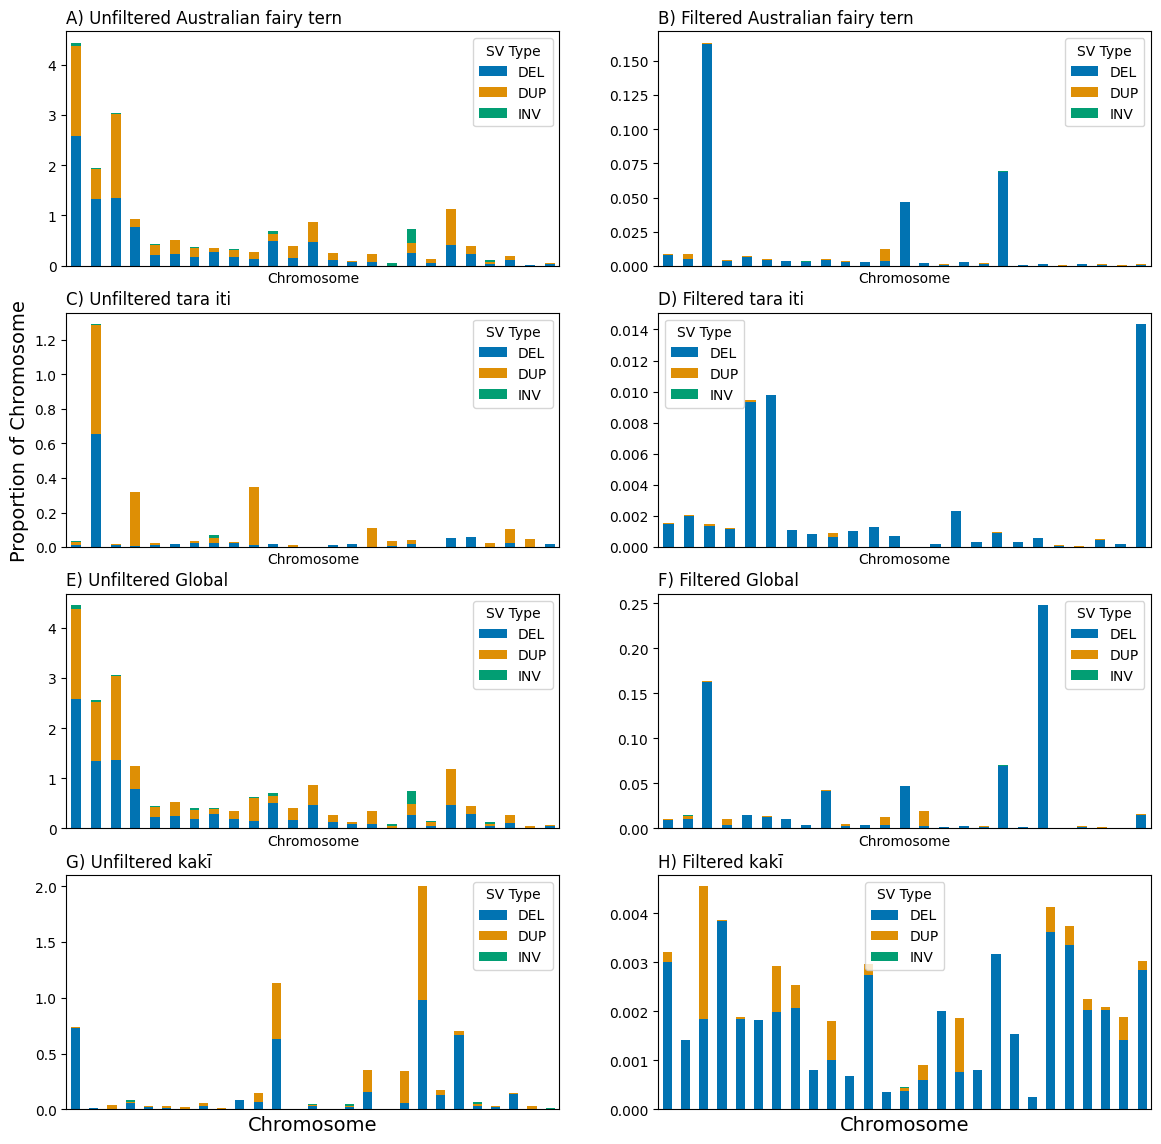

In [20]:
palette = {
    'BND': '#56b4e9',
    'DEL': '#0173b2',
    'DUP': '#de8f05',
    'INV': '#029e73'
}
order = ['BND', 'DEL', 'DUP', 'INV']

def plot_stacked_bar(df, dataset_filter, ax, title):
    df_filtered = df[df['Dataset'] == dataset_filter]
    pivot_df = df_filtered.pivot(index='Chromosome', columns='SV Type', values='Chr Proportion')
    pivot_df = pivot_df.fillna(0)
    
    pivot_df.plot(kind='bar', stacked=True, color=[palette.get(x) for x in pivot_df.columns], ax=ax)
    
    ax.set_title(title, fontsize=12, loc='left')
    ax.set_xticks([])
    ax.legend(title='SV Type')

fig, axes = plt.subplots(4, 2, figsize=(14, 14), sharex=False, sharey=False)

plot_stacked_bar(auSV_prop, 'Smoove Unfiltered', axes[0,0], 'A) Unfiltered Australian fairy tern')
plot_stacked_bar(auSV_prop, 'Smoove filtered', axes[0,1], 'B) Filtered Australian fairy tern')
plot_stacked_bar(tiSV_prop, 'Smoove Unfiltered', axes[1,0], 'C) Unfiltered tara iti')
plot_stacked_bar(tiSV_prop, 'Smoove filtered', axes[1,1], 'D) Filtered tara iti')
plot_stacked_bar(glSV_prop, 'Smoove Unfiltered', axes[2,0], 'E) Unfiltered Global')
plot_stacked_bar(glSV_prop, 'Smoove filtered', axes[2,1], 'F) Filtered Global')
plot_stacked_bar(kiSV_prop, 'Smoove Unfiltered', axes[3,0], 'G) Unfiltered kakī')
plot_stacked_bar(kiSV_prop, 'Smoove filtered', axes[3,1], 'H) Filtered kakī')

axes[3,0].set_xlabel('Chromosome', fontsize=14)
axes[3,1].set_xlabel('Chromosome', fontsize=14)
axes[1,0].set_ylabel('Proportion of Chromosome', fontsize=14)

plt.savefig('Git_Repos/2026_S_nereis_Cons_Gen/Figures/SV_chr_props.png', dpi=300, bbox_inches='tight')

In [ ]:
SV_filtered = SVs[SVs['Dataset']=='Filtered']
SV_filtered['SV Length'] = SV_filtered['SV Length'].astype(int)
SV_filtered.groupby('Population')['SV Length'].sum().reset_index(name='Total BP Impacted')

### SV Length Distributions

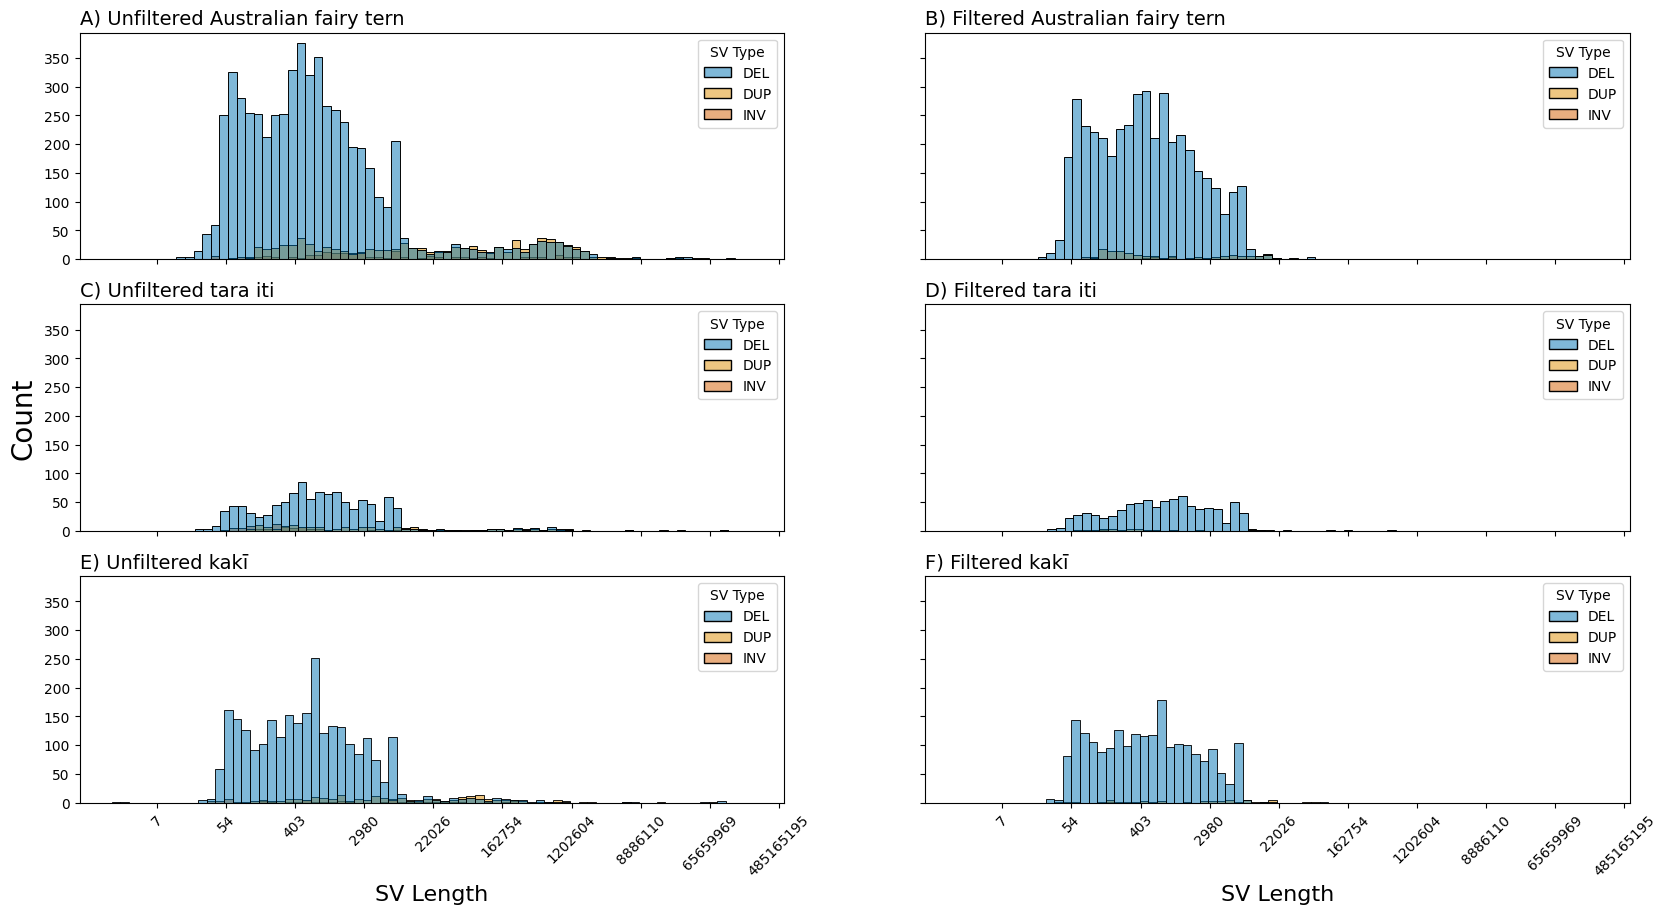

In [2]:
SVs = pd.read_csv('smoove/SV_characteristics.tsv', delimiter='\t')
SVs = SVs[SVs['SV Type']!='.']
SVs['Length'] = pd.to_numeric(SVs['Length'], errors='coerce')
SVs['Log Length'] = np.log(SVs['Length'])

auSVs = SVs[SVs['Population']=='AU']
tiSVs = SVs[SVs['Population']=='TI']
kiSVs = SVs[SVs['Population']=='KI']

palette = {'DEL': '#0173b2', 'DUP': '#de8f05', 'INV': '#d55e00'}
order = ['DEL', 'DUP', 'INV']
populations = {'AU': auSVs, 'TI': tiSVs, 'KI': kiSVs}
titles = {'AU': 'Australian fairy tern', 'TI': 'tara iti', 'KI': 'kakī'}

fig, axes = plt.subplots(3, 2, figsize=(20, 10), sharex=True, sharey=True)

x_ticks_log = np.arange(2, 22, 2)
x_labels = np.exp(x_ticks_log).astype(int)

sns.histplot(auSVs[auSVs['Dataset'] == 'Smoove Unfiltered'], x='Log Length', hue='SV Type', palette=palette, hue_order=order, binwidth=0.25, ax=axes[0, 0])
axes[0, 0].set_title('A) Unfiltered Australian fairy tern', fontsize=14, loc='left')
axes[0, 0].set_xticks(x_ticks_log)
axes[0, 0].set_ylabel('')
sns.histplot(auSVs[auSVs['Dataset'] == 'Smoove filtered'], x='Log Length', hue='SV Type', palette=palette, hue_order=order, binwidth=0.25, ax=axes[0, 1])
axes[0, 1].set_title('B) Filtered Australian fairy tern', fontsize=14, loc='left')
axes[0, 1].set_xticks(x_ticks_log)

sns.histplot(tiSVs[tiSVs['Dataset'] == 'Smoove Unfiltered'], x='Log Length', hue='SV Type', palette=palette, hue_order=order, binwidth=0.25, ax=axes[1, 0])
axes[1, 0].set_title('C) Unfiltered tara iti', fontsize=14, loc='left')
axes[1, 0].set_xticks(x_ticks_log)
axes[1, 0].set_ylabel('Count', fontsize=20)
sns.histplot(tiSVs[tiSVs['Dataset'] == 'Smoove filtered'], x='Log Length', hue='SV Type', palette=palette, hue_order=order, binwidth=0.25, ax=axes[1, 1])
axes[1, 1].set_title('D) Filtered tara iti', fontsize=14, loc='left')
axes[1, 1].set_xticks(x_ticks_log)

sns.histplot(kiSVs[kiSVs['Dataset'] == 'Smoove Unfiltered'], x='Log Length', hue='SV Type', palette=palette, hue_order=order, binwidth=0.25, ax=axes[2, 0])
axes[2, 0].set_title('E) Unfiltered kakī', fontsize=14, loc='left')
axes[2, 0].set_xticks(x_ticks_log)
axes[2, 0].set_ylabel('')
axes[2, 0].set_xticklabels(x_labels, rotation=45)
axes[2, 0].set_xlabel('SV Length', fontsize=16)
sns.histplot(kiSVs[kiSVs['Dataset'] == 'Smoove filtered'], x='Log Length', hue='SV Type', palette=palette, hue_order=order, binwidth=0.25, ax=axes[2, 1])
axes[2, 1].set_title('F) Filtered kakī', fontsize=14, loc='left')
axes[2, 1].set_xticks(x_ticks_log)
axes[2, 1].set_xticklabels(x_labels, rotation=45)
axes[2, 1].set_xlabel('SV Length', fontsize=16)

plt.savefig('Git_Repos/2026_S_nereis_Cons_Gen/Figures/Supp_Fig_SV_log_length_distributions.png', dpi=300, bbox_inches='tight')

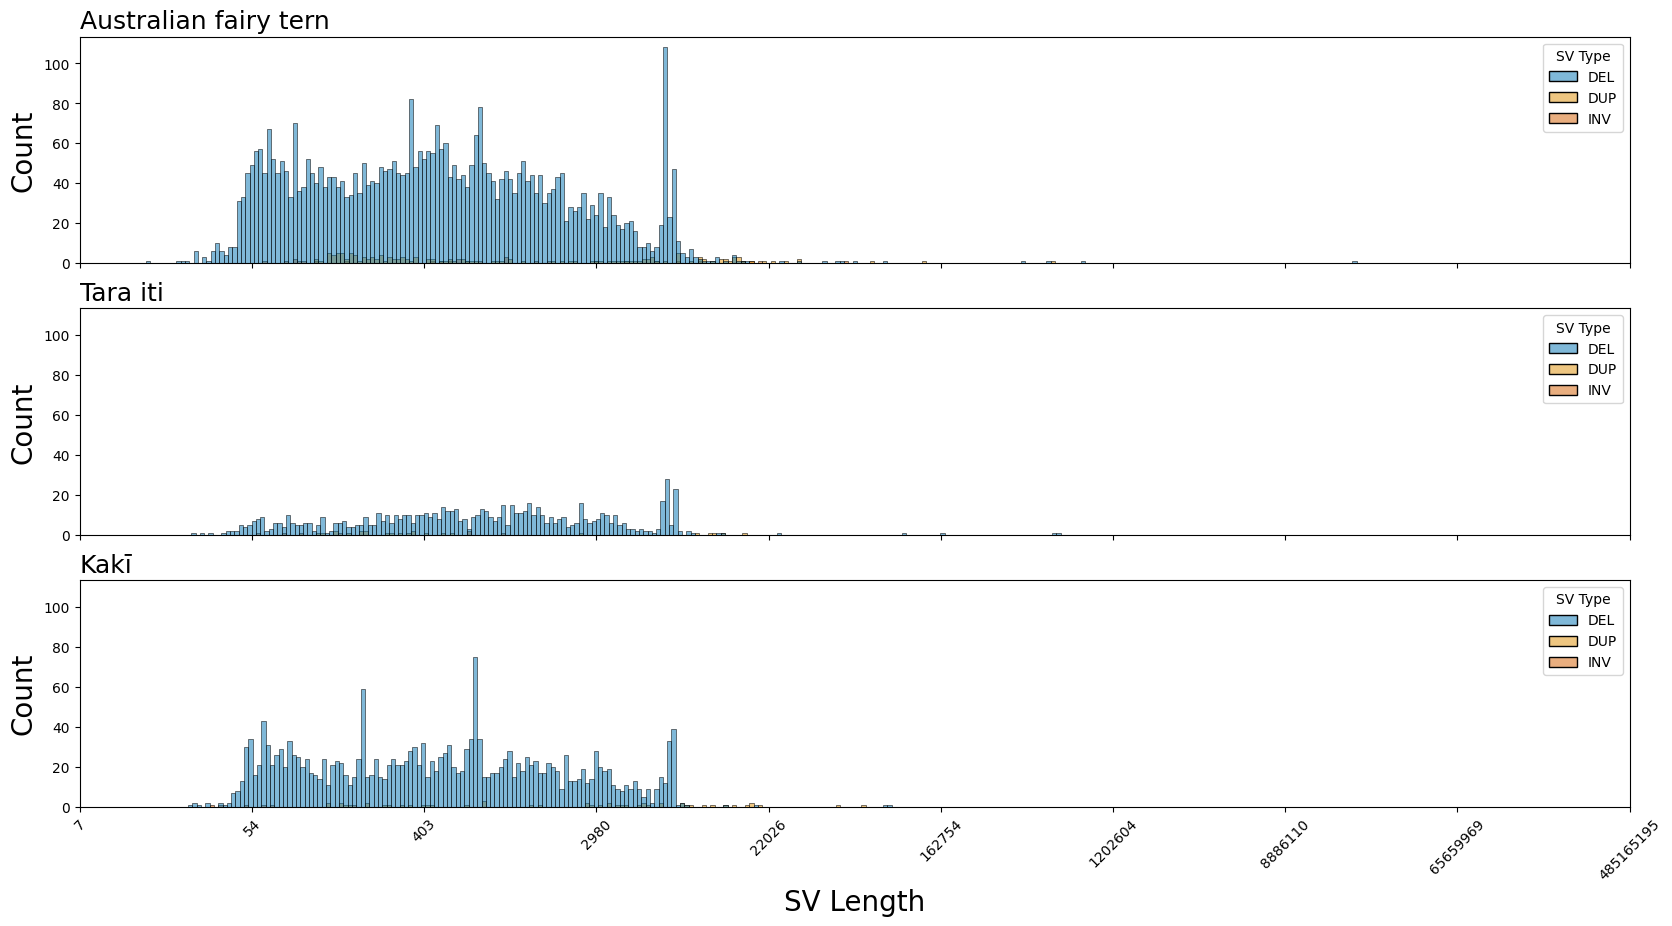

In [3]:
SVs = pd.read_csv('smoove/SV_characteristics.tsv', delimiter='\t')
SVs = SVs[SVs['SV Type']!='.']
SVs['Length'] = pd.to_numeric(SVs['Length'], errors='coerce')
SVs['Log Length'] = np.log(SVs['Length'])

auSVs = SVs[SVs['Population']=='AU']
tiSVs = SVs[SVs['Population']=='TI']
kiSVs = SVs[SVs['Population']=='KI']

palette = {'DEL': '#0173b2', 'DUP': '#de8f05', 'INV': '#d55e00'}
order = ['DEL', 'DUP', 'INV']
populations = {'AU': auSVs, 'TI': tiSVs, 'KI': kiSVs}
titles = {'AU': 'Australian fairy tern', 'TI': 'tara iti', 'KI_10x': 'low coverage kakī', 'KI': 'kakī'}

fig, axes = plt.subplots(3, 1, figsize=(20, 10), sharex=True, sharey=True)

x_ticks_log = np.arange(2, 22, 2)
x_labels = np.exp(x_ticks_log).astype(int)

sns.histplot(auSVs[auSVs['Dataset'] == 'Smoove filtered'], x='Log Length', hue='SV Type', binwidth=0.05, palette=palette, hue_order=order, ax=axes[0])
axes[0].set_title('Australian fairy tern', fontsize=18, loc='left')
axes[0].set_xticks(x_ticks_log)
axes[0].set_ylabel('Count', fontsize=20)

sns.histplot(tiSVs[tiSVs['Dataset'] == 'Smoove filtered'], x='Log Length', hue='SV Type', binwidth=0.05, palette=palette, hue_order=order, ax=axes[1])
axes[1].set_title('Tara iti', fontsize=18, loc='left')
axes[1].set_xticks(x_ticks_log)
axes[1].set_ylabel('Count', fontsize=20)

sns.histplot(kiSVs[kiSVs['Dataset'] == 'Smoove filtered'], x='Log Length', hue='SV Type', binwidth=0.05, palette=palette, hue_order=order, ax=axes[2])
axes[2].set_title('Kakī', fontsize=18, loc='left')
axes[2].set_xticks(x_ticks_log)
axes[2].set_xticklabels(x_labels, rotation=45)
axes[2].set_xlabel('SV Length', fontsize=20)
axes[2].set_ylabel('Count', fontsize=20)

plt.savefig('Git_Repos/2026_S_nereis_Cons_Gen/Figures/Supp_Fig_SV_log_length_filtered_distributions.png', dpi=300, bbox_inches='tight')

## SV Evaluation
Genotypes were visually inspected for support by plotting with SAMplot and scoring with [PlotCritic](https://github.com/jbelyeu/PlotCritic). As with Smeds et al. only one curator was used to prevent the overfiltering of genotypes. We used BCFtools to first extract regions of interest for each individual.
```
bcftools view -i 'SVTYPE=!"INS" & GT=="RR"' -f [%CHROM\t%POS\t%END\t%SVTYPE\t%SAMPLE\thomRef\n]' 02_fairy_genotypes_filtered.vcf.gz > fairy_samplot_regions.tsv
bcftools view -i 'SVTYPE=!"INS" & GT=="het"' -f [%CHROM\t%POS\t%END\t%SVTYPE\t%SAMPLE\thet\n]' 02_fairy_genotypes_filtered.vcf.gz >> fairy_samplot_regions.tsv
bcftools view -i 'SVTYPE=!"INS" & GT=="AA"' -f [%CHROM\t%POS\t%END\t%SVTYPE\t%SAMPLE\thomAlt\n]' 02_fairy_genotypes_filtered.vcf.gz >> fairy_samplot_regions.tsv

bcftools view -i 'SVTYPE=!"INS" & GT=="RR"' -f [%CHROM\t%POS\t%END\t%SVTYPE\t%SAMPLE\thomRef\n]' 02_kaki_genotypes_filtered.vcf.gz > kaki_samplot_regions.tsv
bcftools view -i 'SVTYPE=!"INS" & GT=="het"' -f [%CHROM\t%POS\t%END\t%SVTYPE\t%SAMPLE\thet\n]' 02_kaki_genotypes_filtered.vcf.gz >> kaki_samplot_regions.tsv
bcftools view -i 'SVTYPE=!"INS" & GT=="AA"' -f [%CHROM\t%POS\t%END\t%SVTYPE\t%SAMPLE\thomAlt\n]' 02_kaki_genotypes_filtered.vcf.gz >> kaki_samplot_regions.tsv
```

These regions were then plotted into individual folders with SAMPLOT.  
```
while read -r line
    do
    CHROM=$(echo $line | awk '{print $1})
    START=$(echo $line | awk '{print $2})
    ENDIN=$(echo $line | awk '{print $3})
    SVTYP=$(echo $line | awk '{print $4})
    SAMPL=$(echo $line | awk '{print $5})
    GENOS=$(echo $line | awk '{print $6})
    printf "STARTED SAMPLOT FOR $SAMPL ${CHROM}:${START} AT "
    date
    samplot plot -n ${SAMPL} -b alignments/${SAMPL}_nodup_autosomes.bam \
        -o fairy_SAMplot/${SVTYP}_${CHROM}_${START}_${ENDIN}_${SAMPLE}_${GENOS}.png \
        -c $CHROM \
        -s $START \
        -e $ENDIN \
        -t $SVTYP
done < fairy_samplot_regions.tsv
```
This was then repeated for kakī genotypes.  

We then created PlotCritic projects and manually scored all SV genotypes.  
```
plotcritic -p fairy_genos -i fairy_SAMplot/ -q "What is the Genotype? -A "a":"HomRef" "b":"Het" "c":"HomAlt"
plotcritic -p kaki_genos -i kaki_SAMplot/ -q "What is the Genotype? -A "a":"HomRef" "b":"Het" "c":"HomAlt"
```
Scored genotypes were then extracted from the PlotCritic Summary files upon completion of scoring.  
```
printf "Chromosome\tPosition\tEnd\tSV_type\tSample\tGraphTyper_GT\thomRef_score\thet_score\thomAlt_score\n" > {kaki,fairy}_scores.tsv
tail -n+4 fairy_genos/fairy_genos_summary_report.tsv | tr '_' '\t' | awk '{print $2"_"$3"\t"$4"\t"$5"\t"$1"\t"$6"\t"$7"\t"$8"\t"$9"\t"$10}' >> fairy_scores.tsv

printf "Chromosome\tPosition\tEnd\tSV_Type\tSample\tGraphTyper_GT\tPlotCritic_GT\n" > fairy_genos.tsv
tail -n+2 fairy_scores.tsv | awk '{if ($7==100) print $1"\t"$2"\t"$3"\t"$4"\t"$5"\t"$6"\t0";
    else if ($8==100) print $1"\t"$2"\t"$3"\t"$4"\t"$5"\t"$6"\t1";
    else if ($9==100) print $1"\t"$2"\t"$3"\t"$4"\t"$5"\t"$6"\t2"}' >> fairy_genos.tsv

tail -n+4 kaki_genos/kaki_genos_summary_report.tsv | tr '_' '\t' | awk '{print $2"_"$3"\t"$4"\t"$5"\t"$1"\t$6"\t"$7"\t"$8"\t"$9"\t"$10}' >> kaki_scores.tsv
awk '{if ($7==100) print $1"\t"$3"\t"$3"\t"$4"\t"$5"\t"$6"\t0";
    else if ($8==100) print $1"\t"$3"\t"$3"\t"$4"\t"$5"\t"$6"\t1";
    else if ($9==100) print $1"\t"$3"\t"$3"\t"$4"\t"$5"\t"$6"\t2"}' kaki_scores.tsv >> kaki_genos.tsv
```


The number counts of each genotype for each individual were then acquired as below.  

In [ ]:
tail -n+2 fairy_genos.tsv | cut -f5,7 | sort | uniq -c

## Population Structure and Differentiation
### MDS
We prepared the called SVs for ngsDist by using BCFtools to output the posterior probabilities (`FORMAT/PL`) for each individual's genotype.  

In [ ]:
bcftools query -f '%CHROM\t%POS\t[%PL\t]\n' graphtyper/02_fairy_genotypes_filtered.vcf.gz | sed 's/,/\t/g' | gzip -c > graphtyper/fairy_mds/fairy_SVgenos.tsv.gz

NSITES=$(zcat graphtyper/fairy_mds/fairy_SVgenos.tsv.gz | wc -l)
ngsDist --geno graphtyper/fairy_mds/fairy_SVgenos.tsv.gz --probs --log_scale \
    -n_ind 34 -n_sites $NSITES -labels graphtyper/fairy_mds/mds_list -o graphtyper/fairy_mds/GLOBAL_svDist

tail -n +3 graphtyper/fairy_mds/GLOBAL_svDist | Rscript --vanilla --slave getMDS.R \
    --no_header --data_symm -n 4 -m "mds" -o graphtyper/fairy_mds/GLOBAL_sv.mds

## Intersections with BUSCO genes
After calling BUSCO sites for the tara iti and kakī genome assemblies, we extracted regions corresponding with complete, single-copy BUSCOs and those regions corresponding to our autosomal chromosomes.  

In [ ]:
cut -f2,3,4,5 run_aves_odb10/full_table.tsv | grep Complete | awk '{print $2"\t"$3"\t"$4"\t"$5}' > SP01_scBUSCOs.bed

while read -r line
    do
    CHROM=(echo $line | awk '{print $1}')
    printf "EXTRACTING CHROMOSOME $CHROM...\n"
    grep "$CHROM" SP01_scBUSCOs.bed >> SP01_autosome_scBUSCOs.bed
done < SP01_autosomes2.bed

sort -k1,1 -k2,2n SP01_autosome_scBUSCOs.bed > SP01_autosome_scBUSCOs.sorted.bed

After extracting BUSCOs corresponding to our autosomal scaffolds, we identified SVs overlapping these genes by extracting SV regions and finding intersecting sites with BCFtools and BEDtools.  

In [ ]:
bcftools query -f '%CHROM\t%POS\t%SVLEN\n' 02_fairy_genotypes_filtered.vcf.gz | awk '{print $1"\t"$2"\t"$2+$3}' | sort -k1,1 -k2,2n > fairy_sv.bed

bedtools intersect -wa -a fairy_sv.bed  -b SP01_autsome_scBUSCOs.sorted.bed | awk '{print $1"\t"$2}' > fairy_BUSCO_svs.txt

bcftools view -T fairy_BUSCO_svs.txt -O z -o 03_fairy_BUSCO.vcf.gz 02_fairy_genotypes_filtered.vcf.gz